# Notebook 03 — Oportunidade de Opex
## M&A em Logística B2B: Análise de Savings com Roteirizador da LogiPrime

**Objetivo:** Estimar as oportunidades de redução de custos operacionais (Opex) para a RotaSul com a adoção do roteirizador da LogiPrime, baseado em três alavancas de otimização:
- **17% de redução** em quilometragem percorrida
- **23% de redução** em tempo de deslocamento
- **35% de redução** em tempo de espera no cliente

**Estrutura do Notebook:**
1. Setup e Premissas Formais
2. Saving em Manutenção
3. Saving em Combustível
4. Saving em Hora Extra (Análise Complexa)
5. Consolidação Executiva
6. Análise de Sensibilidade
7. Notas Metodológicas


---
## Seção 0 — Setup e Premissas Formais


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configurar matplotlib para português e melhor visualização
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')

# Definir diretórios
BASE_DIR = Path('..').resolve()
DATA_PROCESSED = BASE_DIR / 'data' / '03_processed'
RESULTS_DIR = BASE_DIR / 'results' / '03_opex'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Diretório base: {BASE_DIR}")
print(f"Diretório de resultados: {RESULTS_DIR}")

Diretório base: D:\UERJ\Programacao_e_Codigos\PRG00_Case M&A em Logistica
Diretório de resultados: D:\UERJ\Programacao_e_Codigos\PRG00_Case M&A em Logistica\results\03_opex


### 0.1 — Declaração de Premissas

Todas as premissas são registradas como constantes nomeadas para garantir rastreabilidade e facilitar análise de sensibilidade posterior.


In [2]:
# ALAVANCAS DE OTIMIZAÇÃO DO ROTEIRIZADOR DA LOGIPRIME
REDUCAO_KM = 0.17                    # 17% de redução na quilometragem
REDUCAO_TEMPO_TRECHO = 0.23          # 23% de redução no tempo de deslocamento
REDUCAO_TEMPO_ESPERA = 0.35          # 35% de redução no tempo de espera no cliente

# CUSTOS UNITÁRIOS (Dados Adicionais do Case)
CUSTO_MANUTENCAO_KM = 1.31           # R$ 1,31 / km
CUSTO_COMBUSTIVEL_KM = 4.07          # R$ 4,07 / km
CUSTO_HE_MOTORISTA_H = 36.00         # R$ 36 / hora extra (motorista)
CUSTO_HE_AJUDANTE_H = 22.00          # R$ 22 / hora extra (ajudante)
CUSTO_HE_TOTAL_H = CUSTO_HE_MOTORISTA_H + CUSTO_HE_AJUDANTE_H  # R$ 58/h

# Saving combinado por km (manutenção + combustível)
CUSTO_TOTAL_KM = CUSTO_MANUTENCAO_KM + CUSTO_COMBUSTIVEL_KM  # R$ 5,38 / km

# PARÂMETROS OPERACIONAIS
JORNADA_PADRAO_MIN = 440             # Jornada padrão em minutos (exclui First Mile e retorno ao CD)
DIAS_OPERACIONAIS_ANO = 250          # Aproximação de dias úteis / operacionais por ano

# CAPACIDADES DE FROTA (para análises posteriores)
CAPACIDADES = {
    'VUC': {'peso_kg': 3000, 'volume_m3': 20},
    'Toco': {'peso_kg': 6000, 'volume_m3': 40},
    'Truck': {'peso_kg': 12000, 'volume_m3': 60},
    'Carreta': {'peso_kg': 25000, 'volume_m3': 100},
}

print(" Premissas carregadas com sucesso")
print(f"\nResumo de Custos Unitários:")
print(f"  • Manutenção: R$ {CUSTO_MANUTENCAO_KM}/km")
print(f"  • Combustível: R$ {CUSTO_COMBUSTIVEL_KM}/km")
print(f"  • Total por km: R$ {CUSTO_TOTAL_KM}/km")
print(f"  • Hora Extra (Motorista + Ajudante): R$ {CUSTO_HE_TOTAL_H}/h")
print(f"\nResumo de Alavancas de Otimização:")
print(f"  • Redução de km: {REDUCAO_KM*100:.0f}%")
print(f"  • Redução de tempo em deslocamento: {REDUCAO_TEMPO_TRECHO*100:.0f}%")
print(f"  • Redução de tempo de espera: {REDUCAO_TEMPO_ESPERA*100:.0f}%")

 Premissas carregadas com sucesso

Resumo de Custos Unitários:
  • Manutenção: R$ 1.31/km
  • Combustível: R$ 4.07/km
  • Total por km: R$ 5.380000000000001/km
  • Hora Extra (Motorista + Ajudante): R$ 58.0/h

Resumo de Alavancas de Otimização:
  • Redução de km: 17%
  • Redução de tempo em deslocamento: 23%
  • Redução de tempo de espera: 35%


### 0.2 — Carregamento de Dados e Construção da Base de Cálculo (Nível Rota)


In [3]:
# Carregar dados limpos do Notebook 02
cols_necessarias = [
    'empresa', 'codigo_rota', 'data_rota', 'uf', 'tipo_veiculo', 'placa_veiculo',
    'km_total_rota', 'km_retorno_base', 'tempo_trecho_min', 
    'tempo_espera_pdv_min', 'tempo_descarga_pdv_min',
    'peso_kg_total_rota', 'volume_m3_total_rota', 'num_entregas_rota'
]

df_limpo = pd.read_parquet(DATA_PROCESSED / 'dados_limpos.parquet',columns=cols_necessarias,filters=[('empresa', '==', 'RotaSul')])

print(f"Shape do dataset completo: {df_limpo.shape}")
print(f"\nEmpresas presentes: {df_limpo['empresa'].unique()}")
print(f"\nDistribuição por empresa:")
print(df_limpo['empresa'].value_counts())

# Filtrar apenas RotaSul (a otimização aplica-se à empresa adquirida)
df_rotas_raw = df_limpo[df_limpo['empresa'] == 'RotaSul'].copy()

print(f"\n RotaSul filtrada: {df_rotas_raw.shape[0]} registros")
print(f"\nRegistros por UF (RotaSul):")
print(df_rotas_raw['uf'].value_counts())

Shape do dataset completo: (438788, 14)

Empresas presentes: ['RotaSul']

Distribuição por empresa:
empresa
RotaSul    438788
Name: count, dtype: int64

 RotaSul filtrada: 438788 registros

Registros por UF (RotaSul):
uf
PR    175767
SC    132722
RS    130299
Name: count, dtype: int64


In [4]:
# Construir base de cálculo no nível rota (codigo_rota como chave única)
# Agregações necessárias por rota

df_rotas = df_rotas_raw.groupby('codigo_rota', as_index=False).agg({
    # Informações identificadoras
    'data_rota': 'first',
    'uf': 'first',
    'tipo_veiculo': 'first',
    'placa_veiculo': 'first',
    
    # Distâncias
    'km_total_rota': 'first',  # Já consolidado em nível rota
    'km_retorno_base': 'first',  # Calculado no Notebook 01 de limpeza
    
    # Tempos
    'tempo_trecho_min': 'sum',        # Soma de todos os trechos
    'tempo_espera_pdv_min': 'sum',    # Soma de todas as esperas
    'tempo_descarga_pdv_min': 'sum',  # Soma de todas as descargas
    
    # Pesos e volumes
    'peso_kg_total_rota': 'first',
    'volume_m3_total_rota': 'first',
    'num_entregas_rota': 'first',
})

# Calcular variáveis derivadas essenciais para o análise
df_rotas['km_total_efetivo'] = df_rotas['km_total_rota'] + df_rotas['km_retorno_base'].fillna(0)
df_rotas['tempo_total_rota_min'] = df_rotas['tempo_trecho_min'] + df_rotas['tempo_espera_pdv_min'] + df_rotas['tempo_descarga_pdv_min']
df_rotas['minutos_he_atuais'] = np.maximum(0, df_rotas['tempo_total_rota_min'] - JORNADA_PADRAO_MIN)
df_rotas['flag_he_atual'] = df_rotas['minutos_he_atuais'] > 0

# Garantir que km_retorno_base não contenha NaN
df_rotas['km_retorno_base'] = df_rotas['km_retorno_base'].fillna(0)

print(f" Base de cálculo construída: {df_rotas.shape[0]} rotas únicas")
print(f"\nMétricas principais (RotaSul):")
print(f"  • KM total efetivo: {df_rotas['km_total_efetivo'].sum():,.0f} km")
print(f"  • Tempo total de rotas: {df_rotas['tempo_total_rota_min'].sum():,.0f} min ({df_rotas['tempo_total_rota_min'].sum()/60:,.0f} h)")
print(f"  • Rotas em hora extra: {df_rotas['flag_he_atual'].sum()} ({df_rotas['flag_he_atual'].sum()/len(df_rotas)*100:.1f}%)")
print(f"  • Total de minutos em HE: {df_rotas['minutos_he_atuais'].sum():,.0f} min ({df_rotas['minutos_he_atuais'].sum()/60:,.0f} h)")

df_rotas.head()

 Base de cálculo construída: 62800 rotas únicas

Métricas principais (RotaSul):
  • KM total efetivo: 20,449,667 km
  • Tempo total de rotas: 29,282,314 min (488,039 h)
  • Rotas em hora extra: 35446 (56.4%)
  • Total de minutos em HE: 4,333,075 min (72,218 h)


,codigo_rota,data_rota,uf,tipo_veiculo,placa_veiculo,km_total_rota,km_retorno_base,tempo_trecho_min,tempo_espera_pdv_min,tempo_descarga_pdv_min,peso_kg_total_rota,volume_m3_total_rota,num_entregas_rota,km_total_efetivo,tempo_total_rota_min,minutos_he_atuais,flag_he_atual
0,B_PR_20240101_B-CAR-00000,2024-01-01,PR,CARRETA,B-CAR-00000,202.605679,0.0,195.549804,111.839087,149.408873,19755.197620,77.008873,9,202.605679,456.797764,16.797764,True
1,B_PR_20240101_B-CAR-00006,2024-01-01,PR,CARRETA,B-CAR-00006,332.245528,0.0,250.080715,51.272759,78.385951,19347.455026,76.562187,5,332.245528,379.739425,0.000000,False
2,B_PR_20240101_B-CAR-00008,2024-01-01,PR,CARRETA,B-CAR-00008,485.026611,0.0,367.806896,115.725928,96.886933,18068.043265,75.364102,7,485.026611,580.419757,140.419757,True
3,B_PR_20240101_B-CAR-00010,2024-01-01,PR,CARRETA,B-CAR-00010,152.373993,0.0,115.484179,28.161769,51.468853,18873.524311,75.451043,3,152.373993,195.114801,0.000000,False
4,B_PR_20240101_B-CAR-00011,2024-01-01,PR,CARRETA,B-CAR-00011,289.139034,0.0,243.767344,86.302325,137.097194,17701.338763,71.539025,8,289.139034,467.166863,27.166863,True


---
## Seção 1 — Saving em Manutenção


**Lógica:** A redução de 17% na quilometragem reduz proporcionalmente o desgaste do veículo (pneus, revisões, peças), gerando economia direta no custo de manutenção.


In [5]:
# 1.1 — Cálculo do Saving em Manutenção

df_rotas['km_reduzido'] = df_rotas['km_total_efetivo'] * REDUCAO_KM
df_rotas['saving_manutencao'] = df_rotas['km_reduzido'] * CUSTO_MANUTENCAO_KM

# Consolidar por UF e Tipo de Veículo
saving_manutencao_uf = df_rotas.groupby('uf')['saving_manutencao'].sum().sort_values(ascending=False)
saving_manutencao_veiculo = df_rotas.groupby('tipo_veiculo')['saving_manutencao'].sum().sort_values(ascending=False)
saving_manutencao_total = df_rotas['saving_manutencao'].sum()
total_km_reduzido = df_rotas['km_reduzido'].sum()

print("=" * 70)
print("SAVING EM MANUTENÇÃO")
print("=" * 70)
print(f"\nTotal de KM Reduzidos: {total_km_reduzido:,.0f} km")
print(f"\nSaving Total Anual (RotaSul): R$ {saving_manutencao_total:,.2f}")

print(f"\nPor Estado:")
for uf, valor in saving_manutencao_uf.items():
    pct = valor / saving_manutencao_total * 100
    print(f"  {uf}: R$ {valor:,.2f} ({pct:.1f}%)")

print(f"\nPor Tipo de Veículo:")
for veiculo, valor in saving_manutencao_veiculo.items():
    pct = valor / saving_manutencao_total * 100
    print(f"  {veiculo}: R$ {valor:,.2f} ({pct:.1f}%)")

SAVING EM MANUTENÇÃO

Total de KM Reduzidos: 3,476,443 km

Saving Total Anual (RotaSul): R$ 4,554,140.84

Por Estado:
  PR: R$ 1,829,709.49 (40.2%)
  SC: R$ 1,375,154.49 (30.2%)
  RS: R$ 1,349,276.85 (29.6%)

Por Tipo de Veículo:
  TRUCK: R$ 3,185,486.79 (69.9%)
  CARRETA: R$ 1,368,654.05 (30.1%)


- A adoção do roteirizador da LogiPrime, ao promover uma redução de 17% na quilometragem percorrida pela RotaSul, gera uma economia direta e imediata nos custos de manutenção da frota. Ao aplicar a tarifa de R$ 1,31/km sobre os 3,47 milhões de quilômetros que seriam eliminados anualmente da operação, chega-se a um saving total de R$ 4,55 milhões por ano, o que mostra ser um número expressivo que decorre diretamente da extensão das rotas regionais da RotaSul, muito superiores em distância absoluta às rotas urbanas da LogiPrime.

- A distribuição geográfica do saving de manutenção segue proporcionalmente o volume de km rodado em cada estado. O Paraná concentra 40,2% da economia (R$ 1,83 M), seguido por Santa Catarina com 30,2% (R$ 1,37 M) e Rio Grande do Sul com 29,6% (R$ 1,35 M). Essa distribuição é coerente com o peso operacional de cada estado na base da RotaSul, onde o PR responde pelo maior volume de rotas, com 175.767 registros, contra 132.722 em SC e 130.299 no RS. Do ponto de vista da estratégia de implantação, o Paraná apresenta o maior retorno absoluto por estado e deve ser priorizado no rollout do sistema.

In [6]:
# 1.2 — Análise Cruzada: UF x Tipo de Veículo

saving_manutencao_cruzado = df_rotas.pivot_table(
    values='saving_manutencao',
    index='uf',
    columns='tipo_veiculo',
    aggfunc='sum',
    margins=True,
    margins_name='Total'
)

print("\nSaving em Manutenção por Estado e Tipo de Veículo (R$):")
print(saving_manutencao_cruzado.fillna(0).astype(int))


Saving em Manutenção por Estado e Tipo de Veículo (R$):
tipo_veiculo  CARRETA    TRUCK    Total
uf                                     
PR             544739  1284969  1829709
RS             404674   944602  1349276
SC             419240   955914  1375154
Total         1368654  3185486  4554140


- A segmentação por tipo de veículo revela uma concentração ainda mais marcante, sendo os TRUCKs respondem por 69,9% do saving total de manutenção (R$ 3,19 M), enquanto as CARRETAs respondem pelos 30,1% restantes (R$ 1,37 M). Esse resultado é intuitivo, pois os TRUCKs são a categoria dominante na frota da RotaSul (70% do mix), percorrendo volumes absolutos de quilometragem superiores. A análise cruzada Estado × Veículo confirma que a maior concentração individual de saving está em TRUCK no PR (R$ 1,28 M), seguida por TRUCK em SC (R$ 956 K) e TRUCK no RS (R$ 945 K).

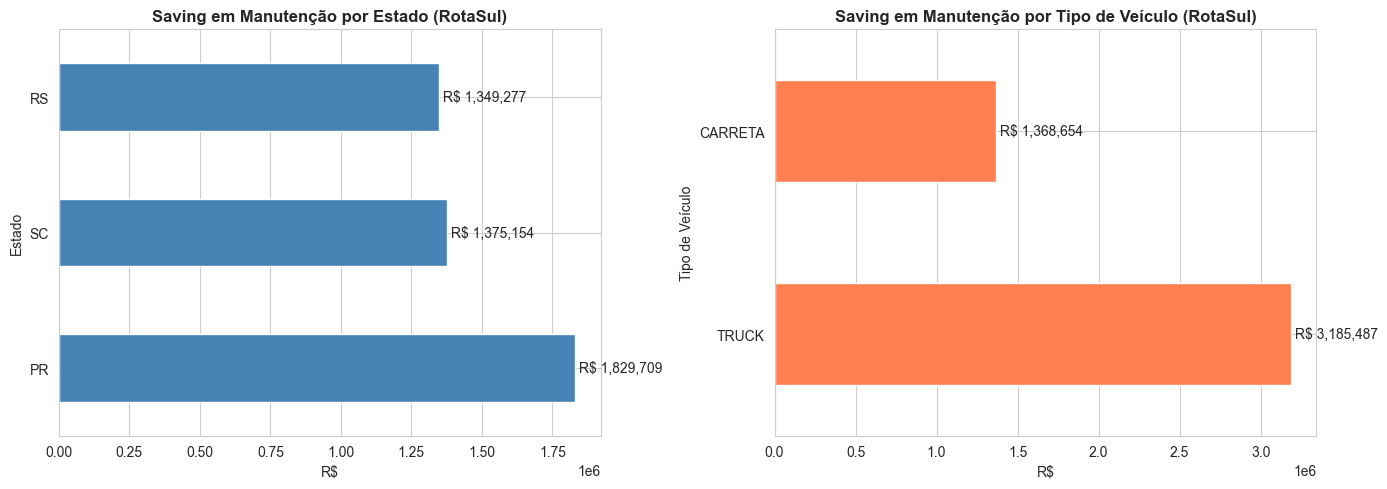

Gráfico salvo: 01_saving_manutencao.png


In [7]:
# 1.3 — Visualização: Saving em Manutenção por UF e Veículo

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico por UF
ax1 = axes[0]
saving_manutencao_uf.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Saving em Manutenção por Estado (RotaSul)', fontsize=12, fontweight='bold')
ax1.set_xlabel('R$')
ax1.set_ylabel('Estado')
for i, v in enumerate(saving_manutencao_uf.values):
    ax1.text(v, i, f' R$ {v:,.0f}', va='center')

# Gráfico por Tipo de Veículo
ax2 = axes[1]
saving_manutencao_veiculo.plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Saving em Manutenção por Tipo de Veículo (RotaSul)', fontsize=12, fontweight='bold')
ax2.set_xlabel('R$')
ax2.set_ylabel('Tipo de Veículo')
for i, v in enumerate(saving_manutencao_veiculo.values):
    ax2.text(v, i, f' R$ {v:,.0f}', va='center')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_saving_manutencao.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico salvo: 01_saving_manutencao.png")

- Vale destacar um ponto metodológico relevante: o saving de manutenção, assim como o de combustível, é uma função linear direta da quilometragem reduzida. Qualquer quilômetro eliminado gera economia imediata, sem efeitos de limiar ou não-linearidade. Isso torna essa alavanca a mais previsível e de menor risco de frustração de expectativa entre os três componentes analisados.

---
## Seção 2 — Saving em Combustível


**Lógica:** Mesma alavanca de quilometragem (17%), porém com tarifa unitária maior (R$ 4,07/km vs. R$ 1,31/km), tornando este o maior saving absoluto dos três componentes de custo.


In [8]:
# 2.1 — Cálculo do Saving em Combustível

df_rotas['saving_combustivel'] = df_rotas['km_reduzido'] * CUSTO_COMBUSTIVEL_KM

# Consolidar por UF e Tipo de Veículo
saving_combustivel_uf = df_rotas.groupby('uf')['saving_combustivel'].sum().sort_values(ascending=False)
saving_combustivel_veiculo = df_rotas.groupby('tipo_veiculo')['saving_combustivel'].sum().sort_values(ascending=False)
saving_combustivel_total = df_rotas['saving_combustivel'].sum()

# Ratio combustível / manutenção
ratio_combust_manut = saving_combustivel_total / saving_manutencao_total

print("=" * 70)
print("SAVING EM COMBUSTÍVEL")
print("=" * 70)
print(f"\nSaving Total Anual (RotaSul): R$ {saving_combustivel_total:,.2f}")
print(f"Ratio Combustível / Manutenção: {ratio_combust_manut:.2f}x")
print(f"\nPor Estado:")
for uf, valor in saving_combustivel_uf.items():
    pct = valor / saving_combustivel_total * 100
    print(f"  {uf}: R$ {valor:,.2f} ({pct:.1f}%)")

print(f"\nPor Tipo de Veículo:")
for veiculo, valor in saving_combustivel_veiculo.items():
    pct = valor / saving_combustivel_total * 100
    print(f"  {veiculo}: R$ {valor:,.2f} ({pct:.1f}%)")

SAVING EM COMBUSTÍVEL

Saving Total Anual (RotaSul): R$ 14,149,124.59
Ratio Combustível / Manutenção: 3.11x

Por Estado:
  PR: R$ 5,684,669.95 (40.2%)
  SC: R$ 4,272,426.56 (30.2%)
  RS: R$ 4,192,028.07 (29.6%)

Por Tipo de Veículo:
  TRUCK: R$ 9,896,894.07 (69.9%)
  CARRETA: R$ 4,252,230.51 (30.1%)


- O saving em combustível compartilha exatamente a mesma alavanca operacional do saving em manutenção (redução de 17% na quilometragem ), mas com uma tarifa unitária 3,1 vezes maior (R$ 4,07/km vs. R$ 1,31/km). Esse diferencial de tarifa transforma o combustível no maior componente individual de saving, totalizando R$ 14,15 milhões anuais, o equivalente a 65% do saving total identificado na análise.

In [9]:
# 2.3 — Saving Combinado por Quilômetro Otimizado (Manutenção + Combustível)

df_rotas['saving_km_total'] = df_rotas['saving_manutencao'] + df_rotas['saving_combustivel']
saving_km_total = df_rotas['saving_km_total'].sum()

print(f"\nSaving Combinado por KM Otimizado:")
print(f"  • Manutenção + Combustível: R$ {CUSTO_TOTAL_KM:.2f} por km")
print(f"  • Total de km reduzido: {df_rotas['km_reduzido'].sum():,.0f} km")
print(f"  • Saving total km-dependente: R$ {saving_km_total:,.2f}")


Saving Combinado por KM Otimizado:
  • Manutenção + Combustível: R$ 5.38 por km
  • Total de km reduzido: 3,476,443 km
  • Saving total km-dependente: R$ 18,703,265.42


- O ratio de 3,11× entre o saving de combustível e o de manutenção é um dado estratégico relevante para o estudo de caso, pois ele demonstra que o impacto financeiro da ineficiência quilométrica da RotaSul é amplificado principalmente pelo custo de combustível, e não pelo desgaste do veículo. Em termos práticos, cada 1.000 km eliminados da operação valem R$ 4.070 em combustível e R$ 1.310 em manutenção, o que juntos somam R$ 5.380 por 1.000 km otimizados, o que constitui o custo combinado por quilômetro mais relevante para o business case da fusão.


Top 10 Rotas por Saving (Manutenção + Combustível):
              codigo_rota uf tipo_veiculo  km_total_efetivo  num_entregas_rota  saving_manutencao  saving_combustivel  saving_total_rota
B_RS_20240618_B-TRK-00038 RS        TRUCK        931.437075                  2         207.431037          644.461312         851.892348
B_RS_20240919_B-CAR-00021 RS      CARRETA        916.347741                  2         204.070642          634.021002         838.091644
B_PR_20241011_B-TRK-00051 PR        TRUCK        874.644724                  2         194.783380          605.166685         799.950065
B_PR_20241214_B-CAR-00016 PR      CARRETA        808.935244                  3         180.149879          559.702295         739.852174
B_SC_20240529_B-TRK-00121 SC        TRUCK        769.650710                  3         171.401213          532.521326         703.922539
B_PR_20240215_B-TRK-00063 PR        TRUCK        748.659455                  4         166.726461          517.997477        

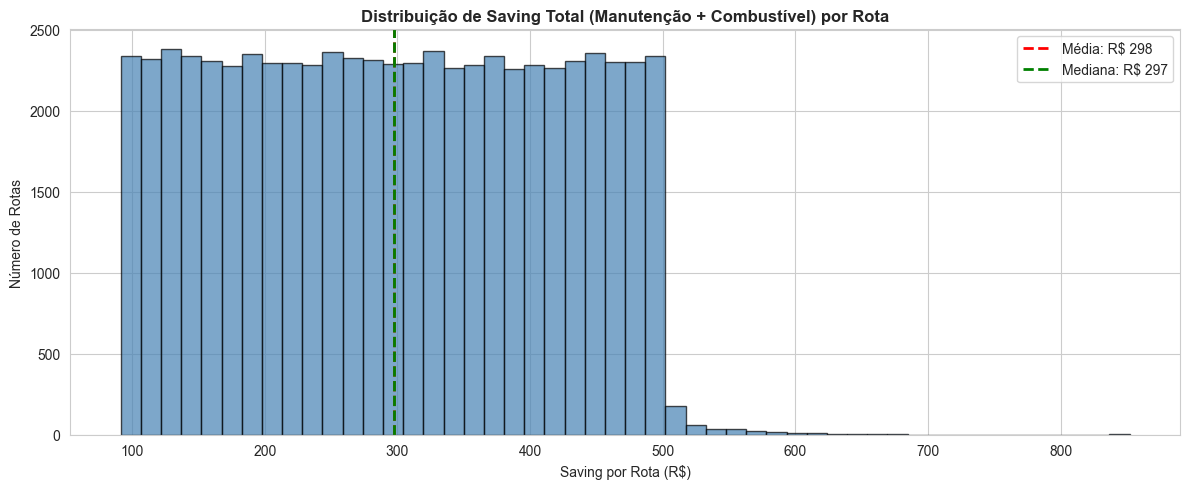

 Gráfico salvo: 02_distribuicao_saving_por_rota.png


In [10]:
# 2.3 — Distribuição de Saving por Rota Individual (Quick Wins)

df_rotas['saving_total_rota'] = df_rotas['saving_manutencao'] + df_rotas['saving_combustivel']  # Ainda sem HE

# Top 10 rotas por saving
top_rotas = df_rotas.nlargest(10, 'saving_total_rota')[[
    'codigo_rota', 'uf', 'tipo_veiculo', 'km_total_efetivo', 'num_entregas_rota',
    'saving_manutencao', 'saving_combustivel', 'saving_total_rota'
]].copy()

print("\nTop 10 Rotas por Saving (Manutenção + Combustível):")
print(top_rotas.to_string(index=False))

# Distribuição: histograma de savings por rota
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df_rotas['saving_total_rota'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Distribuição de Saving Total (Manutenção + Combustível) por Rota', fontsize=12, fontweight='bold')
ax.set_xlabel('Saving por Rota (R$)')
ax.set_ylabel('Número de Rotas')
ax.axvline(df_rotas['saving_total_rota'].mean(), color='red', linestyle='--', linewidth=2, label=f'Média: R$ {df_rotas["saving_total_rota"].mean():,.0f}')
ax.axvline(df_rotas['saving_total_rota'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: R$ {df_rotas["saving_total_rota"].median():,.0f}')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / '02_distribuicao_saving_por_rota.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Gráfico salvo: 02_distribuicao_saving_por_rota.png")

- A distribuição geográfica e por tipo de veículo do saving de combustível replica com precisão o padrão observado na manutenção, o que era esperado pela dependência comum da variável quilometragem. O PR lidera com R$ 5,68 M (40,2%), seguido por SC com R$ 4,27 M (30,2%) e RS com R$ 4,19 M (29,6%). Os TRUCKs concentram 69,9% do saving (R$ 9,90 M) e as CARRETAs os 30,1% restantes (R$ 4,25 M).

- A análise de distribuição do saving por rota individual entrega um insight operacional concreto. A média de saving km-dependente (manutenção + combustível) por rota é de R$ 298, com mediana de R$ 297, uma distribuição notavelmente simétrica, o que indica que o benefício está relativamente bem distribuído entre as rotas e não concentrado em poucos outliers. O histograma confirma essa homogeneidade, com a maioria das rotas gerando entre R$ 100 e R$ 600 de saving por rota.

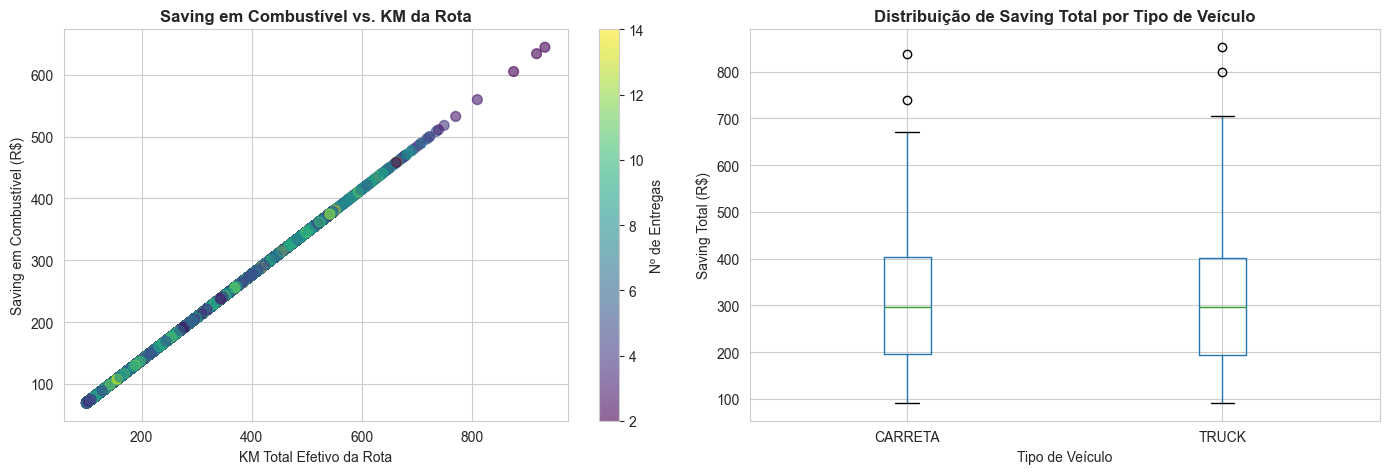

 Gráfico salvo: 02b_scatter_combustivel.png


In [11]:
# 2.4 — Scatter Plot: Saving vs. KM Total da Rota

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot geral
ax1 = axes[0]
scatter = ax1.scatter(df_rotas['km_total_efetivo'], df_rotas['saving_combustivel'], 
                       c=df_rotas['num_entregas_rota'], cmap='viridis', alpha=0.6, s=50)
ax1.set_title('Saving em Combustível vs. KM da Rota', fontsize=12, fontweight='bold')
ax1.set_xlabel('KM Total Efetivo da Rota')
ax1.set_ylabel('Saving em Combustível (R$)')
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Nº de Entregas')

# Boxplot por Tipo de Veículo
ax2 = axes[1]
df_rotas.boxplot(column='saving_total_rota', by='tipo_veiculo', ax=ax2)
ax2.set_title('Distribuição de Saving Total por Tipo de Veículo', fontsize=12, fontweight='bold')
ax2.set_xlabel('Tipo de Veículo')
ax2.set_ylabel('Saving Total (R$)')
plt.suptitle('')  # Remove o título padrão do pandas

plt.tight_layout()
plt.savefig(RESULTS_DIR / '02b_scatter_combustivel.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Gráfico salvo: 02b_scatter_combustivel.png")

- O scatter plot de saving de combustível versus km total da rota revela uma correlação quase perfeitamente linear, o que era esperado matematicamente, dado que o saving é proporcional ao km. A coloração pelo número de entregas mostra que as rotas com maior saving tendem a ter poucas paradas (2 a 4 entregas), confirmando que são as rotas longas e de baixa densidade de paradas, típicas da operação da RotaSul no interior dos estados sulistas, e as que mais se beneficiam da otimização de quilometragem.

- O Top 10 de rotas por saving km-dependente reforça essa lógica, onde as 10 rotas de maior potencial são todas com 2 a 6 entregas, km total acima de 700 km e predominância de TRUCK no RS e CARRETA no RS e PR. Elas representam os quick wins mais evidentes para a fase inicial de implantação do roteirizador, trazendo máximo retorno financeiro com menor complexidade operacional de transição.

---
## Seção 3 — Saving em Hora Extra

**Nota Metodológica Crítica (O Efeito Limiar):**

Diferente do combustível, onde qualquer quilômetro reduzido gera economia imediata, a otimização de tempo **só gera saving financeiro se a rota ultrapassar a jornada de 440 minutos**. Uma rota que cai de 400 para 350 minutos tem saving de hora extra igual a zero. O cálculo abaixo contabiliza apenas rotas que efetivamente saem da zona de hora extra ou reduzem o tempo excedente.


In [12]:
# 3.1 — Aplicação das Otimizações de Tempo

# Otimizar tempos conforme as alavancas do roteirizador
df_rotas['tempo_trecho_otimizado_min'] = df_rotas['tempo_trecho_min'] * (1 - REDUCAO_TEMPO_TRECHO)
df_rotas['tempo_espera_otimizado_min'] = df_rotas['tempo_espera_pdv_min'] * (1 - REDUCAO_TEMPO_ESPERA)
df_rotas['tempo_descarga_total_min'] = df_rotas['tempo_descarga_pdv_min']  # Sem alteração

# Tempo total otimizado
df_rotas['tempo_total_otimizado_min'] = (
    df_rotas['tempo_trecho_otimizado_min'] + 
    df_rotas['tempo_espera_otimizado_min'] + 
    df_rotas['tempo_descarga_total_min']
)

print(" Tempos otimizados calculados")
print(f"\nComparação de Tempos (RotaSul):")
print(f"  Tempo Total Atual: {df_rotas['tempo_total_rota_min'].sum():,.0f} min")
print(f"  Tempo Total Otimizado: {df_rotas['tempo_total_otimizado_min'].sum():,.0f} min")
print(f"    + Tempo Trecho Total Otimizado: {df_rotas['tempo_trecho_otimizado_min'].sum():,.0f} min")
print(f"    + Tempo Espera Total Otimizado: {df_rotas['tempo_espera_otimizado_min'].sum():,.0f} min")
print(f"    + Tempo Descarga Total Atual: {df_rotas['tempo_descarga_total_min'].sum():,.0f} min")
print(f"  Diferença: {df_rotas['tempo_total_rota_min'].sum() - df_rotas['tempo_total_otimizado_min'].sum():,.0f} min ({(df_rotas['tempo_total_rota_min'].sum() - df_rotas['tempo_total_otimizado_min'].sum())/df_rotas['tempo_total_rota_min'].sum()*100:.2f}%)")

 Tempos otimizados calculados

Comparação de Tempos (RotaSul):
  Tempo Total Atual: 29,282,314 min
  Tempo Total Otimizado: 23,534,313 min
    + Tempo Trecho Total Otimizado: 13,106,140 min
    + Tempo Espera Total Otimizado: 3,404,477 min
    + Tempo Descarga Total Atual: 7,023,695 min
  Diferença: 5,748,001 min (19.63%)


- O saving em hora extra é analiticamente o mais rico e estrategicamente o mais complexo dos três componentes, pois combina duas alavancas de tempo simultâneas  redução de 23% no tempo de deslocamento e de 35% no tempo de espera e introduz a não-linearidade do efeito limiar da jornada de 440 minutos. O resultado apurado é um saving total de R$ 3,06 milhões anuais, correspondendo a 14,1% do saving total e à eliminação de aproximadamente 52.789 horas extras ao longo do ano.

In [13]:
# 3.2 — Recálculo de Hora Extra Pós-Otimização

df_rotas['minutos_he_otimizados'] = np.maximum(0, df_rotas['tempo_total_otimizado_min'] - JORNADA_PADRAO_MIN)
df_rotas['minutos_salvos_he'] = df_rotas['minutos_he_atuais'] - df_rotas['minutos_he_otimizados']
df_rotas['horas_he_salvas'] = df_rotas['minutos_salvos_he'] / 60

# Monetização de hora extra
df_rotas['saving_he_motorista'] = df_rotas['horas_he_salvas'] * CUSTO_HE_MOTORISTA_H
df_rotas['saving_he_ajudante'] = df_rotas['horas_he_salvas'] * CUSTO_HE_AJUDANTE_H
df_rotas['saving_he_total'] = df_rotas['horas_he_salvas'] * CUSTO_HE_TOTAL_H

saving_he_total = df_rotas['saving_he_total'].sum()

print("=" * 70)
print("SAVING EM HORA EXTRA")
print("=" * 70)
print(f"\nSaving Total Anual (RotaSul): R$ {saving_he_total:,.2f}")
print(f"\nHoras de Hora Extra Salvas: {df_rotas['horas_he_salvas'].sum():,.0f} h")
print(f"  • Economizadas em Motorista: R$ {df_rotas['saving_he_motorista'].sum():,.2f}")
print(f"  • Economizadas em Ajudante: R$ {df_rotas['saving_he_ajudante'].sum():,.2f}")

SAVING EM HORA EXTRA

Saving Total Anual (RotaSul): R$ 3,061,777.98

Horas de Hora Extra Salvas: 52,789 h
  • Economizadas em Motorista: R$ 1,900,413.92
  • Economizadas em Ajudante: R$ 1,161,364.06


- A premissa adotada para os cálculos é de que toda rota da RotaSul opera com 1 motorista e 1 ajudante. A decomposição entre motorista e ajudante segue o rateio dos custos unitários: R$ 1,90 M economizados com motoristas (R$ 36/h) e R$ 1,16 M com ajudantes (R$ 22/h), totalizando R$ 58/hora extra eliminada. Sendo assim representa o cenário de custo máximo e, portanto, o teto do saving de HE. Caso parte da frota opere sem ajudante, o saving realizado será proporcional à participação de rotas com equipe dupla.

In [14]:
# 3.3 — Matriz de Transição: Classificação de Rotas por Status de HE

# Classificar cada rota em um dos 4 quadrantes
def classificar_status_he(row):
    if row['minutos_he_atuais'] == 0 and row['minutos_he_otimizados'] == 0:
        return 'Mantém dentro'
    elif row['minutos_he_atuais'] > 0 and row['minutos_he_otimizados'] == 0:
        return 'Elimina HE'
    elif row['minutos_he_atuais'] > 0 and row['minutos_he_otimizados'] > 0:
        return 'Reduz HE'
    else:
        return 'Sem impacto'

df_rotas['status_he'] = df_rotas.apply(classificar_status_he, axis=1)

print("\nClassificação de Rotas por Status de Hora Extra:")
status_counts = df_rotas['status_he'].value_counts()
for status, count in status_counts.items():
    pct = count / len(df_rotas) * 100
    print(f"  {status}: {count} rotas ({pct:.1f}%)")

# Resumo de savings por status
print("\nSavings por Status de Rota:")
status_savings = df_rotas.groupby('status_he')['saving_he_total'].agg(['sum', 'count', 'mean']).round(2)
status_savings.columns = ['Saving Total (R$)', 'Nº Rotas', 'Saving Médio (R$)']
print(status_savings)


Classificação de Rotas por Status de Hora Extra:
  Mantém dentro: 27354 rotas (43.6%)
  Elimina HE: 17840 rotas (28.4%)
  Reduz HE: 17606 rotas (28.0%)

Savings por Status de Rota:
               Saving Total (R$)  Nº Rotas  Saving Médio (R$)
status_he                                                    
Elimina HE             923960.16     17840              51.79
Mantém dentro               0.00     27354               0.00
Reduz HE              2137817.83     17606             121.43


- O dado mais revelador desta seção é a matriz de transição de status das rotas, que classifica os 62.800 roteiros em quatro grupos (Mantém dentro, Elimina HE, Reduz HE e Sem impacto). O maior grupo é o Mantém dentro (43,6%, ou 27.354 rotas) já operava dentro da jornada padrão e continua dentro dela após a otimização, ou seja, esse subconjunto não gera saving financeiro de HE, mas confirma que há folga operacional que poderá ser utilizada para expansão de capacidade. O segundo maior grupo é o Elimina HE (28,4%, 17.840 rotas) é formado pelas rotas que eliminam completamente a hora extra, e passam de acima de 440 minutos para abaixo do limite após a otimização, gerando saving médio de R$ 51,79 por rota. O terceiro grupo representa o subconjunto Reduz HE (28,0%, 17.606 rotas) é o das rotas que reduzem mas não eliminam a hora extra, com saving médio superior de R$ 121,43 por rota, sendo as rotas com excedentes maiores de jornada, onde a otimização reduz parcialmente o tempo mas não é suficiente para enquadrá-las nos 440 minutos.

In [15]:
# 3.4 — Segmentação Geográfica do Saving de HE

saving_he_uf = df_rotas.groupby('uf')['saving_he_total'].sum().sort_values(ascending=False)
saving_he_veiculo = df_rotas.groupby('tipo_veiculo')['saving_he_total'].sum().sort_values(ascending=False)

print("\nSaving em Hora Extra por Estado:")
for uf, valor in saving_he_uf.items():
    pct = valor / saving_he_total * 100
    print(f"  {uf}: R$ {valor:,.2f} ({pct:.1f}%)")

print(f"\nSaving em Hora Extra por Tipo de Veículo:")
for veiculo, valor in saving_he_veiculo.items():
    pct = valor / saving_he_total * 100
    print(f"  {veiculo}: R$ {valor:,.2f} ({pct:.1f}%)")


Saving em Hora Extra por Estado:
  PR: R$ 1,233,223.49 (40.3%)
  SC: R$ 924,014.96 (30.2%)
  RS: R$ 904,539.53 (29.5%)

Saving em Hora Extra por Tipo de Veículo:
  TRUCK: R$ 2,142,813.94 (70.0%)
  CARRETA: R$ 918,964.04 (30.0%)


- Um dado contraintuitivo merece atenção, O saving médio por rota do grupo "Reduz HE" (R$ 121,43) é mais que o dobro do grupo "Elimina HE" (R$ 51,79). Isso ocorre porque as rotas que ainda ficam acima de 440 min após a otimização são justamente as que tinham os maiores excedentes iniciais, e portanto, mesmo reduzindo proporcionalmente, ainda geram uma economia absoluta em minutos superior. Isso implica que, para fins de saving de HE, as rotas com jornadas mais longas concentram o maior valor por rota, embora não consigam ser plenamente enquadradas na jornada padrão apenas com as alavancas do roteirizador.

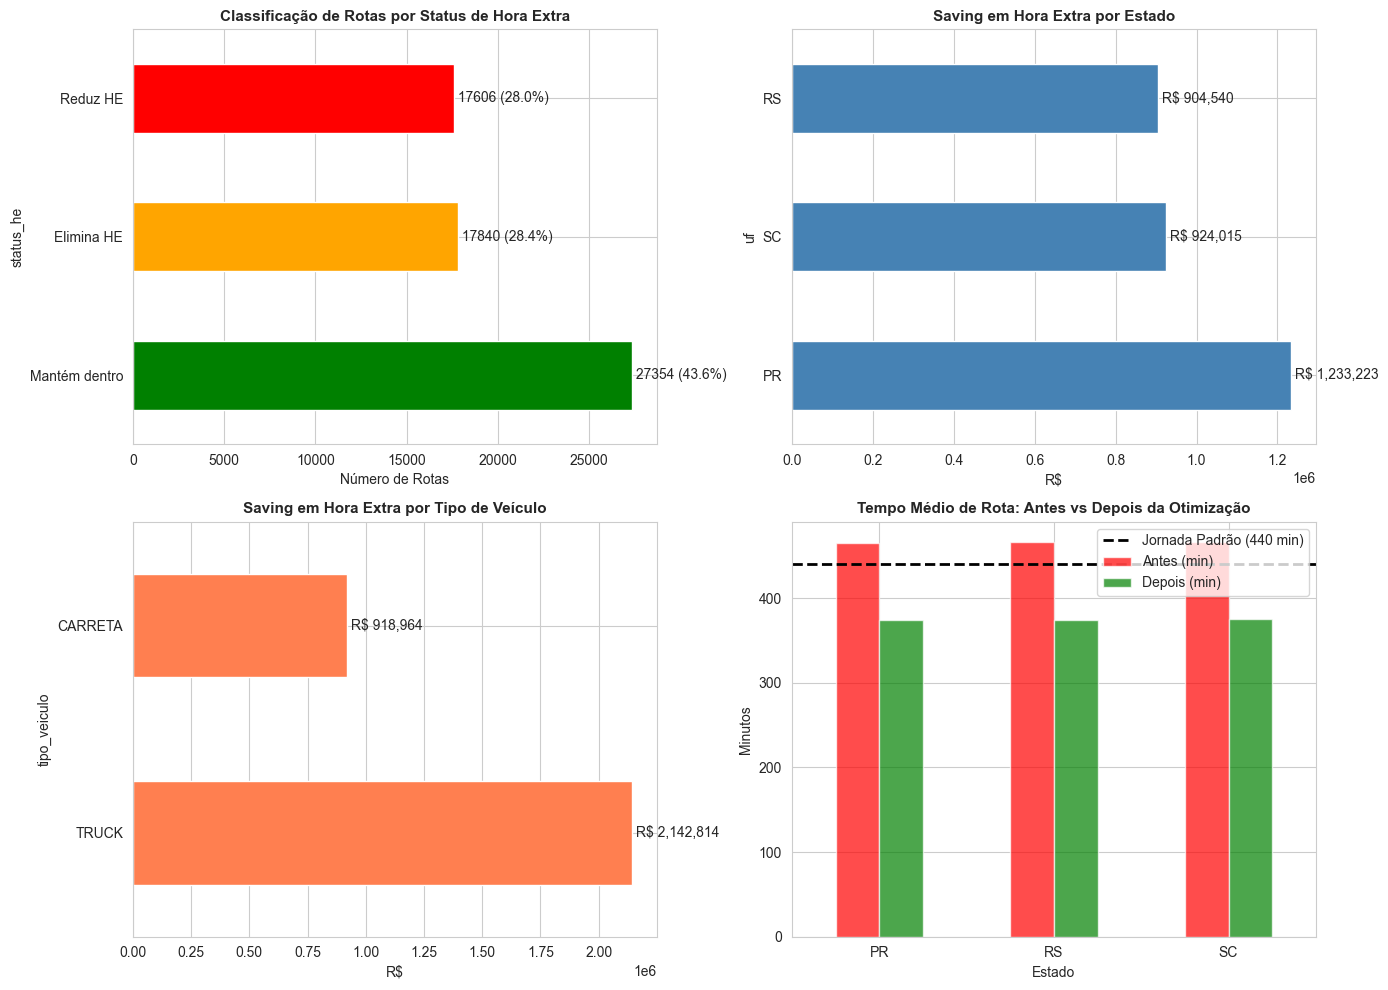

 Gráfico salvo: 03_analise_hora_extra.png


In [16]:
# 3.5 — Visualização: Matriz de Transição e Saving de HE

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Distribuição de Rotas por Status de HE
ax1 = axes[0, 0]
status_counts.plot(kind='barh', ax=ax1, color=['green', 'orange', 'red', 'gray'])
ax1.set_title('Classificação de Rotas por Status de Hora Extra', fontsize=11, fontweight='bold')
ax1.set_xlabel('Número de Rotas')
for i, v in enumerate(status_counts.values):
    ax1.text(v, i, f' {v} ({v/len(df_rotas)*100:.1f}%)', va='center')

# Gráfico 2: Saving de HE por Estado
ax2 = axes[0, 1]
saving_he_uf.plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_title('Saving em Hora Extra por Estado', fontsize=11, fontweight='bold')
ax2.set_xlabel('R$')
for i, v in enumerate(saving_he_uf.values):
    ax2.text(v, i, f' R$ {v:,.0f}', va='center')

# Gráfico 3: Saving de HE por Tipo de Veículo
ax3 = axes[1, 0]
saving_he_veiculo.plot(kind='barh', ax=ax3, color='coral')
ax3.set_title('Saving em Hora Extra por Tipo de Veículo', fontsize=11, fontweight='bold')
ax3.set_xlabel('R$')
for i, v in enumerate(saving_he_veiculo.values):
    ax3.text(v, i, f' R$ {v:,.0f}', va='center')

# Gráfico 4: Box plot de Tempo Antes vs Depois (por Estado)
ax4 = axes[1, 1]
tempo_antes_depois = pd.DataFrame({
    'Antes (min)': df_rotas.groupby('uf')['tempo_total_rota_min'].mean(),
    'Depois (min)': df_rotas.groupby('uf')['tempo_total_otimizado_min'].mean(),
})
tempo_antes_depois.plot(kind='bar', ax=ax4, color=['red', 'green'], alpha=0.7)
ax4.axhline(JORNADA_PADRAO_MIN, color='black', linestyle='--', linewidth=2, label='Jornada Padrão (440 min)')
ax4.set_title('Tempo Médio de Rota: Antes vs Depois da Otimização', fontsize=11, fontweight='bold')
ax4.set_xlabel('Estado')
ax4.set_ylabel('Minutos')
ax4.legend()
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / '03_analise_hora_extra.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Gráfico salvo: 03_analise_hora_extra.png")

- A distribuição geográfica do saving de HE mantém o padrão proporcional ao volume de rotas: PR lidera com R$ 1,23 M (40,3%), SC com R$ 924 K (30,2%) e RS com R$ 905 K (29,5%). Por tipo de veículo, os TRUCKs concentram 70,0% do saving de HE (R$ 2,14 M), resultado coerente com o fato de serem a categoria mais numerosa e de operarem as rotas mais longas em tempo absoluto, portanto, com maior probabilidade de exceder a jornada.

- O gráfico de barras comparativo de tempo médio antes e depois da otimização por estado é o visual mais direto para a análise, pois em todos os três estados, o tempo médio das rotas cai para abaixo da linha de 440 minutos após a aplicação das duas alavancas de tempo. Isso confirma que, em média, o roteirizador é suficiente para enquadrar a operação típica da RotaSul dentro da jornada padrão, embora a distribuição individual das rotas mostre que 28% delas permanecem em situação de hora extra mesmo após a otimização.

---
## Seção 4 — Consolidação Executiva


In [17]:
# 4.1 — Tabela-Resumo dos Três Savings

resumo_savings = pd.DataFrame({
    'Categoria': ['Combustível', 'Manutenção', 'Hora Extra', 'TOTAL'],
    'Alavanca': ['-17% km', '-17% km', '-23% trecho / -35% espera', '—'],
    'Saving Anual (R$)': [
        saving_combustivel_total,
        saving_manutencao_total,
        saving_he_total,
        saving_combustivel_total + saving_manutencao_total + saving_he_total
    ]
})

resumo_savings['% do Total'] = (resumo_savings['Saving Anual (R$)'] / resumo_savings.loc[3, 'Saving Anual (R$)'] * 100).round(1)
resumo_savings_display = resumo_savings.copy()
resumo_savings_display['Saving Anual (R$)'] = resumo_savings_display['Saving Anual (R$)'].apply(lambda x: f'R$ {x:,.2f}')

print("\n" + "=" * 90)
print("RESUMO EXECUTIVO — OPORTUNIDADE DE OPEX (ROTASUL)")
print("=" * 90)
print(resumo_savings_display.to_string(index=False))

total_savings = resumo_savings.loc[3, 'Saving Anual (R$)']
print(f"\n{'SAVING TOTAL ANUAL (R$):':.<50} R$ {total_savings:,.2f}")


RESUMO EXECUTIVO — OPORTUNIDADE DE OPEX (ROTASUL)
  Categoria                  Alavanca Saving Anual (R$)  % do Total
Combustível                   -17% km  R$ 14,149,124.59        65.0
 Manutenção                   -17% km   R$ 4,554,140.84        20.9
 Hora Extra -23% trecho / -35% espera   R$ 3,061,777.98        14.1
      TOTAL                         —  R$ 21,765,043.41       100.0

SAVING TOTAL ANUAL (R$):.......................... R$ 21,765,043.41


- A visão consolidada dos três componentes revela uma oportunidade total de R$ 21,77 milhões anuais de redução de Opex na operação da RotaSul com a adoção do roteirizador da LogiPrime. A composição do saving confirma a dominância do combustível como principal driver de economia: 65,0% do total (R$ 14,15 M), seguido pela manutenção com 20,9% (R$ 4,55 M) e pela hora extra com 14,1% (R$ 3,06 M).

- Essa hierarquia tem uma implicação estratégica importante, o business case da implantação do roteirizador é dominado pela eficiência geométrica das rotas (otimização de km) e não pela eficiência temporal. Isso significa que o impacto financeiro da ferramenta depende, em primeira instância, da qualidade do planejamento de roteiro e não da aderência dos clientes ao agendamento de chegada. É uma vantagem do ponto de vista de risco de implementação, uma vez que a componente de maior valor (65% do saving) é inteiramente controlável pelo gestor de operações, enquanto a componente de espera (que impacta o saving de HE) depende também do comportamento dos clientes da RotaSul.

In [18]:
# 4.2 — Saving Total por Estado

saving_por_estado = df_rotas.groupby('uf').agg({
    'saving_manutencao': 'sum',
    'saving_combustivel': 'sum',
    'saving_he_total': 'sum',
}).reset_index()

saving_por_estado['saving_total'] = (
    saving_por_estado['saving_manutencao'] + 
    saving_por_estado['saving_combustivel'] + 
    saving_por_estado['saving_he_total']
)

saving_por_estado = saving_por_estado.sort_values('saving_total', ascending=False)
saving_por_estado['% do Total'] = (saving_por_estado['saving_total'] / saving_por_estado['saving_total'].sum() * 100).round(1)

print("\nSaving Total por Estado (RotaSul):")
for _, row in saving_por_estado.iterrows():
    print(f"\n  {row['uf']}:")
    print(f"    Combustível: R$ {row['saving_combustivel']:,.2f}")
    print(f"    Manutenção:  R$ {row['saving_manutencao']:,.2f}")
    print(f"    Hora Extra:  R$ {row['saving_he_total']:,.2f}")
    print(f"    TOTAL:       R$ {row['saving_total']:,.2f} ({row['% do Total']:.1f}% do total)")


Saving Total por Estado (RotaSul):

  PR:
    Combustível: R$ 5,684,669.95
    Manutenção:  R$ 1,829,709.49
    Hora Extra:  R$ 1,233,223.49
    TOTAL:       R$ 8,747,602.94 (40.2% do total)

  SC:
    Combustível: R$ 4,272,426.56
    Manutenção:  R$ 1,375,154.49
    Hora Extra:  R$ 924,014.96
    TOTAL:       R$ 6,571,596.01 (30.2% do total)

  RS:
    Combustível: R$ 4,192,028.07
    Manutenção:  R$ 1,349,276.85
    Hora Extra:  R$ 904,539.53
    TOTAL:       R$ 6,445,844.46 (29.6% do total)


- A segmentação por estado confirma o Paraná como o principal foco de valor: R$ 8,75 M (40,2% do total), versus R$ 6,57 M em SC e R$ 6,45 M no RS. Essa concentração no PR não é apenas função do volume de rotas, mas também da extensão média dos roteiros paranaenses, que tendem a cobrir maiores distâncias entre municípios do interior de acordo com os dados fornecidos. Do ponto de vista de rollout, a estratégia ideal seria iniciar a implantação no PR, capturando o maior saving inicial e gerando aprendizado operacional que facilite a expansão para SC e RS em seguida.

In [19]:
# 4.3 — Saving Total por Tipo de Veículo

saving_por_veiculo = df_rotas.groupby('tipo_veiculo').agg({
    'saving_manutencao': 'sum',
    'saving_combustivel': 'sum',
    'saving_he_total': 'sum',
}).reset_index()

saving_por_veiculo['saving_total'] = (
    saving_por_veiculo['saving_manutencao'] + 
    saving_por_veiculo['saving_combustivel'] + 
    saving_por_veiculo['saving_he_total']
)

saving_por_veiculo = saving_por_veiculo.sort_values('saving_total', ascending=False)
saving_por_veiculo['% do Total'] = (saving_por_veiculo['saving_total'] / saving_por_veiculo['saving_total'].sum() * 100).round(1)

print("\nSaving Total por Tipo de Veículo (RotaSul):")
for _, row in saving_por_veiculo.iterrows():
    print(f"\n  {row['tipo_veiculo']}:")
    print(f"    Combustível: R$ {row['saving_combustivel']:,.2f}")
    print(f"    Manutenção:  R$ {row['saving_manutencao']:,.2f}")
    print(f"    Hora Extra:  R$ {row['saving_he_total']:,.2f}")
    print(f"    TOTAL:       R$ {row['saving_total']:,.2f} ({row['% do Total']:.1f}% do total)")


Saving Total por Tipo de Veículo (RotaSul):

  TRUCK:
    Combustível: R$ 9,896,894.07
    Manutenção:  R$ 3,185,486.79
    Hora Extra:  R$ 2,142,813.94
    TOTAL:       R$ 15,225,194.80 (70.0% do total)

  CARRETA:
    Combustível: R$ 4,252,230.51
    Manutenção:  R$ 1,368,654.05
    Hora Extra:  R$ 918,964.04
    TOTAL:       R$ 6,539,848.60 (30.0% do total)


- A visão por tipo de veículo é igualmente clara, os TRUCKs concentram 70,0% do saving total (R$ 15,23 M), enquanto as CARRETAs respondem pelos 30,0% restantes (R$ 6,54 M). Essa concentração nos TRUCKs é esperada dado o mix de frota da RotaSul (70% TRUCK), mas reforça a prioridade de calibrar o roteirizador primeiramente para as rotas operadas por essa categoria.

In [20]:
# 4.4 — Saving Médio por Rota (Métrica Operacional)

df_rotas['saving_total_final'] = (
    df_rotas['saving_manutencao'] + 
    df_rotas['saving_combustivel'] + 
    df_rotas['saving_he_total']
)

print("\nSaving Médio por Rota (RotaSul):")
print(f"  Média:         R$ {df_rotas['saving_total_final'].mean():,.2f}")
print(f"  Mediana:       R$ {df_rotas['saving_total_final'].median():,.2f}")
print(f"  P75:           R$ {df_rotas['saving_total_final'].quantile(0.75):,.2f}")
print(f"  P90:           R$ {df_rotas['saving_total_final'].quantile(0.90):,.2f}")
print(f"  Mínimo:        R$ {df_rotas['saving_total_final'].min():,.2f}")
print(f"  Máximo:        R$ {df_rotas['saving_total_final'].max():,.2f}")


Saving Médio por Rota (RotaSul):
  Média:         R$ 346.58
  Mediana:       R$ 330.12
  P75:           R$ 493.50
  P90:           R$ 581.77
  Mínimo:        R$ 91.47
  Máximo:        R$ 886.81


- Em termos de granularidade operacional, o saving médio por rota é de R$ 346,58, com mediana de R$ 330,12, uma distribuição relativamente equilibrada. O P90 de R$ 581,77 indica que as rotas mais longas e complexas geram quase o dobro do saving médio, justificando a estratégia de quick wins focada nas rotas de maior extensão. 

In [21]:
# 4.5 — Top 10 Rotas (Quick Wins para Implantação)

top_10_rotas = df_rotas.nlargest(10, 'saving_total_final')[[
    'codigo_rota', 'uf', 'tipo_veiculo', 'km_total_efetivo', 'num_entregas_rota',
    'tempo_total_rota_min', 'saving_manutencao', 'saving_combustivel', 'saving_he_total', 'saving_total_final'
]].copy()

# Formatar para apresentação
top_10_display = top_10_rotas.copy()
for col in ['saving_manutencao', 'saving_combustivel', 'saving_he_total', 'saving_total_final']:
    top_10_display[col] = top_10_display[col].apply(lambda x: f'R$ {x:,.0f}')
top_10_display['km_total_efetivo'] = top_10_display['km_total_efetivo'].apply(lambda x: f'{x:.0f} km')
top_10_display['tempo_total_rota_min'] = top_10_display['tempo_total_rota_min'].apply(lambda x: f'{x:.0f} min')

print("\nTop 10 Rotas por Saving Total (Quick Wins para Implantação):")
print(top_10_display.rename(columns={
    'codigo_rota': 'Rota',
    'uf': 'UF',
    'tipo_veiculo': 'Veículo',
    'km_total_efetivo': 'KM',
    'num_entregas_rota': 'Entregas',
    'tempo_total_rota_min': 'Tempo',
    'saving_manutencao': 'Manutencao',
    'saving_combustivel': 'Combustível',
    'saving_he_total': 'HE',
    'saving_total_final': 'Total'
}).to_string(index=False))


Top 10 Rotas por Saving Total (Quick Wins para Implantação):
                     Rota UF Veículo     KM  Entregas   Tempo Manutencao Combustível     HE  Total
B_PR_20241011_B-TRK-00051 PR   TRUCK 875 km         2 530 min     R$ 195      R$ 605  R$ 87 R$ 887
B_RS_20240919_B-CAR-00021 RS CARRETA 916 km         2 457 min     R$ 204      R$ 634  R$ 17 R$ 855
B_RS_20240618_B-TRK-00038 RS   TRUCK 931 km         2 443 min     R$ 207      R$ 644   R$ 3 R$ 855
B_RS_20240515_B-CAR-00051 RS CARRETA 734 km         6 634 min     R$ 164      R$ 508 R$ 128 R$ 800
B_RS_20241202_B-TRK-00107 RS   TRUCK 723 km         4 605 min     R$ 161      R$ 500 R$ 127 R$ 788
B_SC_20240103_B-CAR-00057 SC CARRETA 720 km         5 590 min     R$ 160      R$ 498 R$ 120 R$ 779
B_RS_20240502_B-CAR-00030 RS CARRETA 716 km         5 604 min     R$ 160      R$ 496 R$ 121 R$ 777
B_PR_20240925_B-TRK-00110 PR   TRUCK 706 km         6 639 min     R$ 157      R$ 489 R$ 127 R$ 773
B_SC_20240912_B-TRK-00002 SC   TRUCK 660 km    

- O Top 10 de rotas, com saving máximo de R$ 886,81 por rota, é composto exclusivamente por rotas de TRUCK ou CARRETA com 2 a 8 entregas e km total acima de 700 km, reforçando os candidatos imediatos à fase piloto de implantação.

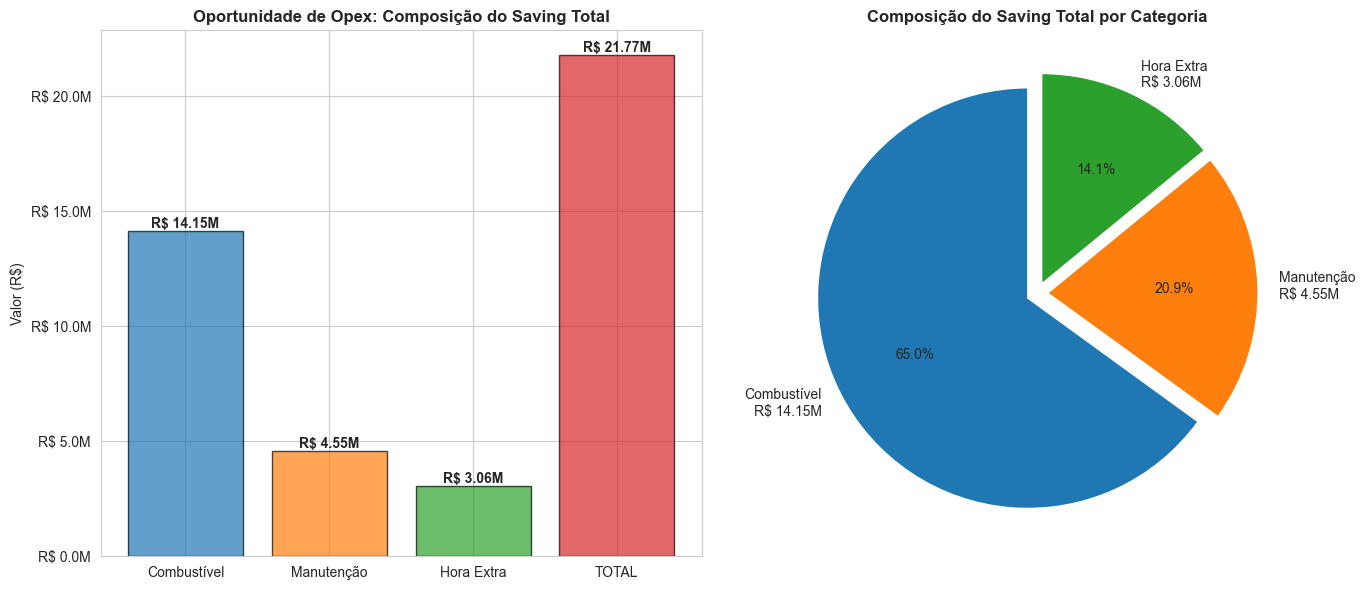

 Gráfico salvo: 04_consolidacao_executiva.png


In [22]:
# 4.6 — Visualização: Waterfall do Saving Total

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Waterfall chart conceptual
ax1 = axes[0]
categories = ['Combustível', 'Manutenção', 'Hora Extra', 'TOTAL']
valores = [
    saving_combustivel_total,
    saving_manutencao_total,
    saving_he_total,
    total_savings
]
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = ax1.bar(categories, valores, color=cores, alpha=0.7, edgecolor='black')
ax1.set_title('Oportunidade de Opex: Composição do Saving Total', fontsize=12, fontweight='bold')
ax1.set_ylabel('Valor (R$)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x/1e6:.1f}M'))

for i, (bar, valor) in enumerate(zip(bars, valores)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'R$ {valor/1e6:.2f}M',
            ha='center', va='bottom', fontweight='bold')

# Pie chart com composição
ax2 = axes[1]
tamanhos = [saving_combustivel_total, saving_manutencao_total, saving_he_total]
labels = [f'Combustível\nR$ {saving_combustivel_total/1e6:.2f}M', 
          f'Manutenção\nR$ {saving_manutencao_total/1e6:.2f}M',
          f'Hora Extra\nR$ {saving_he_total/1e6:.2f}M']
explode = (0.05, 0.05, 0.05)

ax2.pie(tamanhos, labels=labels, autopct='%1.1f%%', colors=cores[:3], explode=explode, startangle=90)
ax2.set_title('Composição do Saving Total por Categoria', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '04_consolidacao_executiva.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Gráfico salvo: 04_consolidacao_executiva.png")

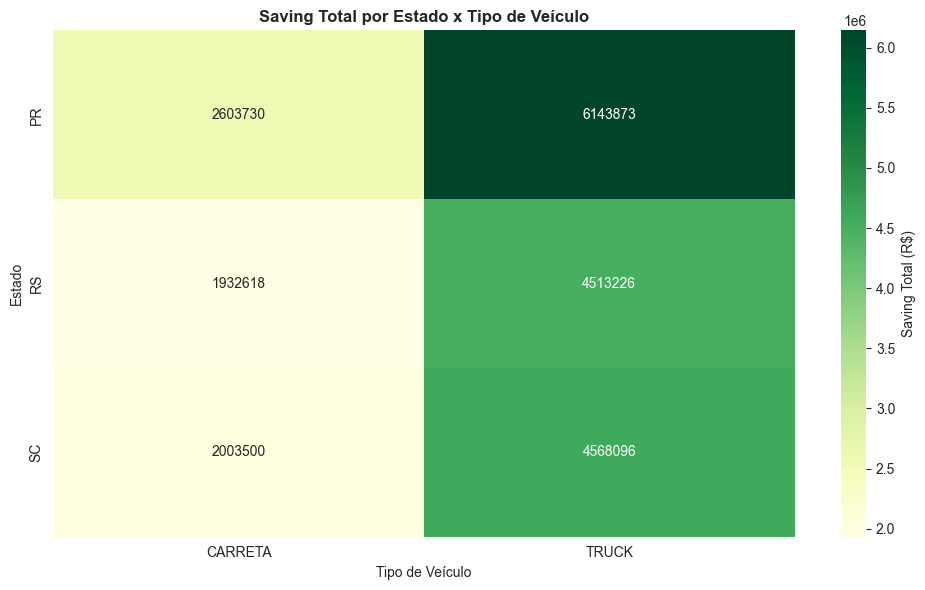

 Gráfico salvo: 04b_heatmap_estado_veiculo.png


In [23]:
# 4.7 — Mapa de Calor: Saving por Estado x Tipo de Veículo

heatmap_data = df_rotas.pivot_table(
    values='saving_total_final',
    index='uf',
    columns='tipo_veiculo',
    aggfunc='sum'
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGn', cbar_kws={'label': 'Saving Total (R$)'}, ax=ax)
ax.set_title('Saving Total por Estado x Tipo de Veículo', fontsize=12, fontweight='bold')
ax.set_xlabel('Tipo de Veículo')
ax.set_ylabel('Estado')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '04b_heatmap_estado_veiculo.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Gráfico salvo: 04b_heatmap_estado_veiculo.png")

---
## Seção 5 — Análise de Sensibilidade

Esta seção transforma o notebook de uma análise de ponto único para uma ferramenta de suporte à decisão executiva, respondendo ao aviso do case: *"Essas premissas devem ser usadas como referência para estimar potencial econômico, não como garantias."*


In [24]:
# 5.1 — Função Paramétrica de Cálculo de Savings

def calcular_savings(df, red_km, red_trecho, red_espera):
    """
    Calcula os três componentes de saving baseado em parâmetros de redução.
    
    Parâmetros:
    - df: DataFrame com dados de rotas
    - red_km: Redução de quilometragem (0-1)
    - red_trecho: Redução de tempo em deslocamento (0-1)
    - red_espera: Redução de tempo em espera (0-1)
    
    Retorna:
    - Dicionário com savings consolidados
    """
    df_temp = df.copy()
    
    # Savings em Combustível e Manutenção (dependem de km)
    km_reduzido = df_temp['km_total_efetivo'] * red_km
    saving_manut = km_reduzido * CUSTO_MANUTENCAO_KM
    saving_combust = km_reduzido * CUSTO_COMBUSTIVEL_KM
    
    # Saving em Hora Extra (depende de tempo)
    tempo_trecho_otim = df_temp['tempo_trecho_min'] * (1 - red_trecho)
    tempo_espera_otim = df_temp['tempo_espera_pdv_min'] * (1 - red_espera)
    tempo_total_otim = tempo_trecho_otim + tempo_espera_otim + df_temp['tempo_descarga_pdv_min']
    
    minutos_he_otim = np.maximum(0, tempo_total_otim - JORNADA_PADRAO_MIN)
    minutos_salvos = np.maximum(0, df_temp['minutos_he_atuais'] - minutos_he_otim)
    saving_he = (minutos_salvos / 60) * CUSTO_HE_TOTAL_H
    
    return {
        'saving_combustivel': saving_combust.sum(),
        'saving_manutencao': saving_manut.sum(),
        'saving_he': saving_he.sum(),
        'saving_total': saving_combust.sum() + saving_manut.sum() + saving_he.sum()
    }

print(" Função de cálculo paramétrico definida")

 Função de cálculo paramétrico definida


In [25]:
# 5.2 — Tabela de Cenários

cenarios = [
    {'nome': 'Conservador', 'red_km': 0.085, 'red_trecho': 0.115, 'red_espera': 0.175},
    {'nome': 'Base', 'red_km': 0.17, 'red_trecho': 0.23, 'red_espera': 0.35},
    {'nome': 'Otimista', 'red_km': 0.25, 'red_trecho': 0.30, 'red_espera': 0.45},
]

resultados_cenarios = []
for cenario in cenarios:
    savings = calcular_savings(df_rotas, cenario['red_km'], cenario['red_trecho'], cenario['red_espera'])
    resultados_cenarios.append({
        'Cenário': cenario['nome'],
        'Redução KM': f"{cenario['red_km']*100:.1f}%",
        'Redução Trecho': f"{cenario['red_trecho']*100:.1f}%",
        'Redução Espera': f"{cenario['red_espera']*100:.1f}%",
        'Saving Combustível': savings['saving_combustivel'],
        'Saving Manutenção': savings['saving_manutencao'],
        'Saving HE': savings['saving_he'],
        'Saving Total': savings['saving_total']
    })

df_cenarios = pd.DataFrame(resultados_cenarios)

print("\n" + "=" * 120)
print("ANÁLISE DE SENSIBILIDADE — CENÁRIOS DE ADOÇÃO")
print("=" * 120)

for _, row in df_cenarios.iterrows():
    print(f"\n{row['Cenário'].upper()}:")
    print(f"  Redução de KM: {row['Redução KM']} | Trecho: {row['Redução Trecho']} | Espera: {row['Redução Espera']}")
    print(f"  └─ Combustível: R$ {row['Saving Combustível']:,.2f}")
    print(f"  └─ Manutenção:  R$ {row['Saving Manutenção']:,.2f}")
    print(f"  └─ Hora Extra:  R$ {row['Saving HE']:,.2f}")
    print(f"  └─ TOTAL:       R$ {row['Saving Total']:,.2f}")


ANÁLISE DE SENSIBILIDADE — CENÁRIOS DE ADOÇÃO

CONSERVADOR:
  Redução de KM: 8.5% | Trecho: 11.5% | Espera: 17.5%
  └─ Combustível: R$ 7,074,562.29
  └─ Manutenção:  R$ 2,277,070.42
  └─ Hora Extra:  R$ 1,742,853.22
  └─ TOTAL:       R$ 11,094,485.93

BASE:
  Redução de KM: 17.0% | Trecho: 23.0% | Espera: 35.0%
  └─ Combustível: R$ 14,149,124.59
  └─ Manutenção:  R$ 4,554,140.84
  └─ Hora Extra:  R$ 3,061,777.98
  └─ TOTAL:       R$ 21,765,043.41

OTIMISTA:
  Redução de KM: 25.0% | Trecho: 30.0% | Espera: 45.0%
  └─ Combustível: R$ 20,807,536.16
  └─ Manutenção:  R$ 6,697,265.94
  └─ Hora Extra:  R$ 3,600,935.31
  └─ TOTAL:       R$ 31,105,737.40


- A análise de sensibilidade é uma ferramenta robusta de suporte à decisão. Ao reconhecer explicitamente que as premissas do roteirizador são referências e não garantias, conforme alertado pelo próprio case, os três cenários calculados fornecem um envelope de resultados que permite entender o risco e o upside da aposta na fusão.

- No cenário conservador, onde as alavancas de otimização atingem metade do esperado (8,5% de redução de km, 11,5% no trecho, 17,5% na espera), o saving total cai para R$ 11,09 milhões anuais, equivalente a 51% do cenário base. Ainda assim, trata-se de uma oportunidade de Opex relevante e de magnitude suficiente para justificar o investimento em implantação do sistema. No cenário otimista, com as premissas superando o estimado (25% km, 30% trecho, 45% espera), o saving sobe para R$ 31,11 milhões anuais, sendo 43% acima do cenário base. O intervalo total entre o pior e o melhor cenário vai de R$ 11 M a R$ 31 M, configurando um range de incerteza de R$ 20 M amplo, mas com piso ainda atrativo.

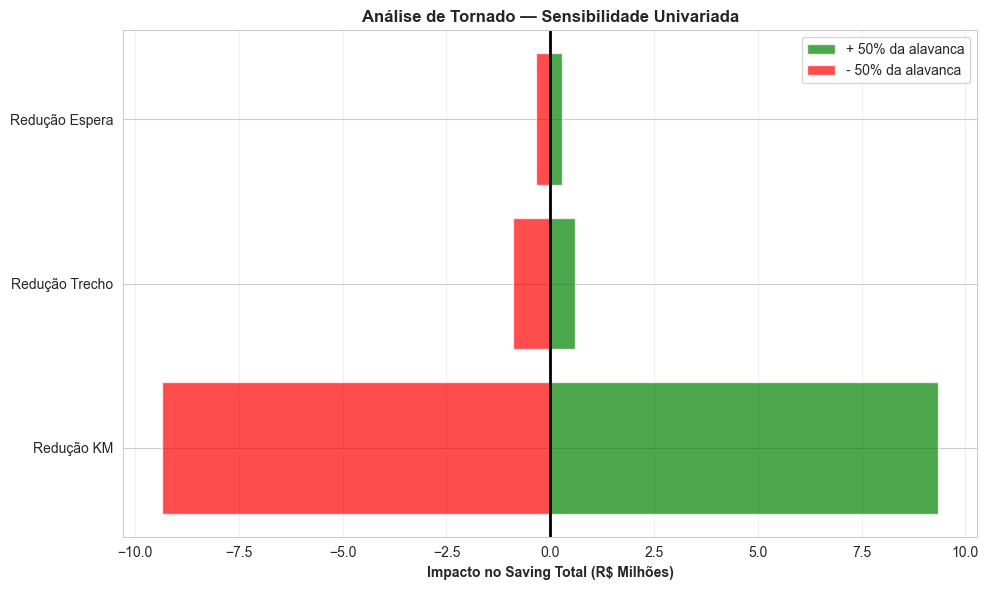

✓ Gráfico salvo: 05b_tornado_sensibilidade.png


In [26]:
# 5.3 — Gráfico de Tornado (Sensibilidade Univariada)

fig, ax = plt.subplots(figsize=(10, 6))

# Calcular impacto de variar cada alavanca em ±25% do valor base
cenario_base = calcular_savings(df_rotas, REDUCAO_KM, REDUCAO_TEMPO_TRECHO, REDUCAO_TEMPO_ESPERA)['saving_total']

impactos = []

# Impacto da variação de KM
menor_km = calcular_savings(df_rotas, REDUCAO_KM * 0.5, REDUCAO_TEMPO_TRECHO, REDUCAO_TEMPO_ESPERA)['saving_total']
maior_km = calcular_savings(df_rotas, REDUCAO_KM * 1.5, REDUCAO_TEMPO_TRECHO, REDUCAO_TEMPO_ESPERA)['saving_total']
impactos.append({'variavel': 'Redução KM', 'menor': (menor_km - cenario_base)/1e6, 'maior': (maior_km - cenario_base)/1e6})

# Impacto da variação de Trecho
menor_trecho = calcular_savings(df_rotas, REDUCAO_KM, REDUCAO_TEMPO_TRECHO * 0.5, REDUCAO_TEMPO_ESPERA)['saving_total']
maior_trecho = calcular_savings(df_rotas, REDUCAO_KM, REDUCAO_TEMPO_TRECHO * 1.5, REDUCAO_TEMPO_ESPERA)['saving_total']
impactos.append({'variavel': 'Redução Trecho', 'menor': (menor_trecho - cenario_base)/1e6, 'maior': (maior_trecho - cenario_base)/1e6})

# Impacto da variação de Espera
menor_espera = calcular_savings(df_rotas, REDUCAO_KM, REDUCAO_TEMPO_TRECHO, REDUCAO_TEMPO_ESPERA * 0.5)['saving_total']
maior_espera = calcular_savings(df_rotas, REDUCAO_KM, REDUCAO_TEMPO_TRECHO, REDUCAO_TEMPO_ESPERA * 1.5)['saving_total']
impactos.append({'variavel': 'Redução Espera', 'menor': (menor_espera - cenario_base)/1e6, 'maior': (maior_espera - cenario_base)/1e6})

# Plotar tornado
y_pos = np.arange(len(impactos))
menores = [imp['menor'] for imp in impactos]
maiores = [imp['maior'] for imp in impactos]

ax.barh(y_pos, maiores, color='green', alpha=0.7, label='+ 50% da alavanca')
ax.barh(y_pos, menores, color='red', alpha=0.7, label='- 50% da alavanca')
ax.axvline(0, color='black', linewidth=2)

ax.set_yticks(y_pos)
ax.set_yticklabels([imp['variavel'] for imp in impactos])
ax.set_xlabel('Impacto no Saving Total (R$ Milhões)', fontweight='bold')
ax.set_title('Análise de Tornado — Sensibilidade Univariada', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / '05b_tornado_sensibilidade.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo: 05b_tornado_sensibilidade.png")

- O gráfico de tornado é a peça mais reveladora da análise de sensibilidade. Ao variar cada alavanca isoladamente em ±50% do seu valor base, fica evidente que a redução de quilometragem é de longe a variável mais sensível do modelo, com um impacto de ±R$ 10 M no saving total frente a uma variação de 50% na premissa. Em contraste, as alavancas de tempo (redução de trecho e de espera) têm impacto individual muito menor, próximo de zero no gráfico de tornado, porque o saving de HE representa apenas 14% do total e ainda está sujeito ao efeito limiar da jornada de 440 minutos.

- Essa assimetria de sensibilidade demonstra que a captura do saving depende fundamentalmente da capacidade do roteirizador de reduzir a quilometragem das rotas da RotaSul. Se a ferramenta entregar a redução de km prometida, o business case está garantido mesmo que os ganhos de tempo sejam menores que o esperado. Por outro lado, se o roteirizador não conseguir otimizar a geometria das rotas regionais do Sul, que possuem características muito diferentes das rotas urbanas para as quais a ferramenta foi originalmente calibrada, o saving potencial encolhe proporcionalmente e de forma muito mais severa do que qualquer variação nos parâmetros de tempo.

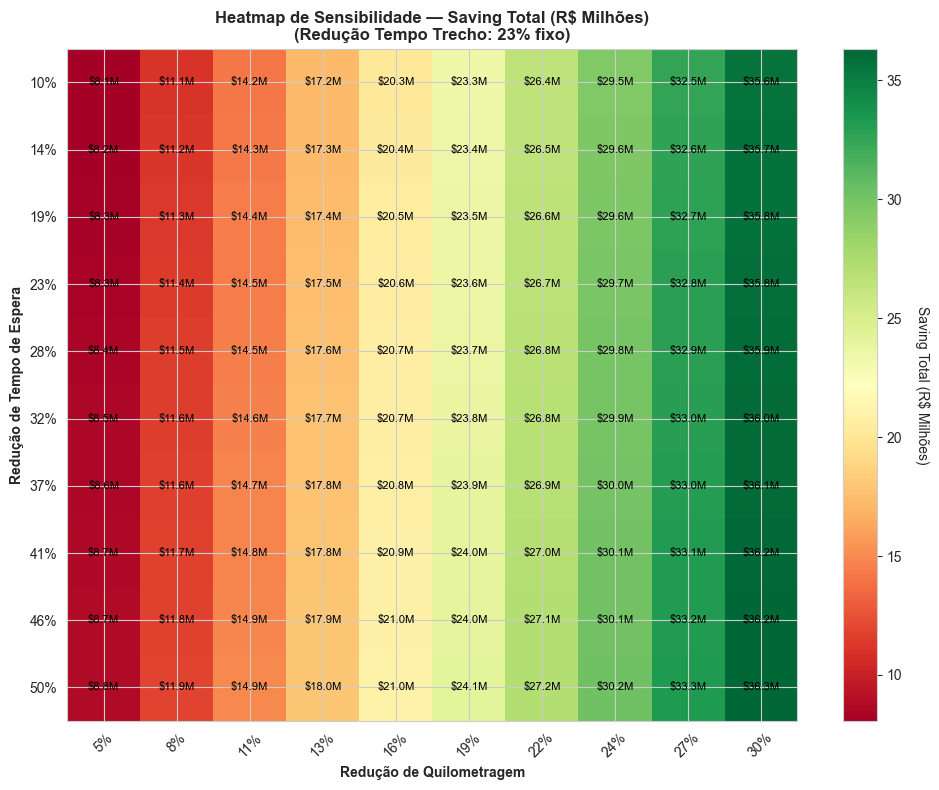

 Gráfico salvo: 05_heatmap_sensibilidade.png


In [27]:
# 5.4 — Heatmap de Sensibilidade (2D)
# Variar redução de KM vs redução de espera

red_km_range = np.linspace(0.05, 0.30, 10)
red_espera_range = np.linspace(0.10, 0.50, 10)

heatmap_sensitivity = np.zeros((len(red_espera_range), len(red_km_range)))

for i, red_espera in enumerate(red_espera_range):
    for j, red_km in enumerate(red_km_range):
        savings = calcular_savings(df_rotas, red_km, REDUCAO_TEMPO_TRECHO, red_espera)
        heatmap_sensitivity[i, j] = savings['saving_total'] / 1e6  # Converter para milhões

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_sensitivity, cmap='RdYlGn', aspect='auto')

# Configurar eixos
ax.set_xticks(range(len(red_km_range)))
ax.set_yticks(range(len(red_espera_range)))
ax.set_xticklabels([f'{x*100:.0f}%' for x in red_km_range], rotation=45)
ax.set_yticklabels([f'{y*100:.0f}%' for y in red_espera_range])

ax.set_xlabel('Redução de Quilometragem', fontweight='bold')
ax.set_ylabel('Redução de Tempo de Espera', fontweight='bold')
ax.set_title('Heatmap de Sensibilidade — Saving Total (R$ Milhões)\n(Redução Tempo Trecho: 23% fixo)', 
            fontsize=12, fontweight='bold')

# Adicionar valores nas células
for i in range(len(red_espera_range)):
    for j in range(len(red_km_range)):
        text = ax.text(j, i, f'${heatmap_sensitivity[i, j]:.1f}M',
                       ha="center", va="center", color="black", fontsize=8)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Saving Total (R$ Milhões)', rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig(RESULTS_DIR / '05_heatmap_sensibilidade.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Gráfico salvo: 05_heatmap_sensibilidade.png")

- O heatmap bidimensional, que cruza a redução de km com a redução de tempo de espera, confirma essa leitura.O gradiente de cor do verde escuro para o vermelho é muito mais intenso na direção horizontal (eixo de redução de km) do que na vertical (eixo de redução de espera), evidenciando que o saving total é muito mais sensível à alavanca geométrica do que à temporal. Isso deve orientar a tomata de decisão  pré-implantação, uma vez que o esforço de validação do roteirizador deve se concentrar em testar sua capacidade de otimização de km em rotas com o perfil da RotaSul, já que longas distâncias, baixa densidade de paradas, malha rodoviária intermunicipal, antes de assumir que as premissas de redução se transferem integralmente da operação urbana da LogiPrime para a operação regional da RotaSul.

---
## Seção 6 — Notas Metodológicas Finais


### Limitações e Considerações Importantes

**Nota 1 — Independência dos Savings de KM (Combustível e Manutenção):**

Os savings de combustível e manutenção são calculados sobre a mesma base de km reduzido (17%) e são independentes entre si. Não há dupla contagem, mas tampouco há efeito multiplicativo entre eles. Ambos derivam exclusivamente da redução de quilometragem.

**Nota 2 — Não-Linearidade da Hora Extra (O Efeito Limiar):**

O saving de hora extra é zero para rotas que já operam dentro da jornada de 440 minutos, independentemente da melhoria de tempo gerada pelo roteirizador. O efeito combinado das duas alavancas de tempo (23% de trecho + 35% de espera) é cumulativo sobre o tempo total, o que pode resultar em um saving de HE superior ao que cada alavanca geraria isoladamente nas rotas em que a espera representa parcela significativa do total.

**Nota 3 — Limitação da Jornada de 440 Minutos:**

A jornada padrão de 440 minutos exclui First Mile (ida até o primeiro ponto) e retorno ao CD, conforme definição do case. Rotas com First Mile longa podem ter hora extra real superior ao que o modelo captura, o que significa que o saving de HE estimado pode ser conservador para esse subconjunto de rotas. Recomenda-se validar essa premissa com dados operacionais da RotaSul.

**Nota 4 — Estrutura de Pessoal por Veículo:**

O custo de hora extra (R$ 58/h) foi calculado assumindo que toda rota da RotaSul opera com 1 motorista + 1 ajudante. Se parte da frota rodar apenas com motorista (ex: VUCs), o saving de HE será menor do que o estimado. Recomenda-se validar essa premissa com a operação.


In [28]:
# Exportar resultados consolidados para Excel e CSV

# 1. Resumo executivo
resumo_executivo = pd.DataFrame({
    'Métrica': [
        'Saving Total Anual (R$)',
        'Rotas Analisadas',
        'Rotas com Hora Extra Atual',
        'Rotas que Eliminam HE',
        'KM Total Reduzido',
        'Horas HE Salvas',
    ],
    'Valor': [
        f"R$ {total_savings:,.2f}",
        f"{len(df_rotas):,}",
        f"{df_rotas['flag_he_atual'].sum():,}",
        f"{(df_rotas['status_he'] == 'Elimina HE').sum():,}",
        f"{df_rotas['km_reduzido'].sum():,.0f}",
        f"{df_rotas['horas_he_salvas'].sum():,.0f}",
    ]
})

# 2. Savings por estado
economia_por_estado = saving_por_estado[['uf', 'saving_combustivel', 'saving_manutencao', 'saving_he_total', 'saving_total']].copy()
economia_por_estado.columns = ['Estado', 'Combustível', 'Manutenção', 'HE', 'Total']

# 3. Top rotas
top_rotas_export = top_10_rotas.copy()
top_rotas_export.columns = ['Rota', 'UF', 'Veículo', 'KM', 'Entregas', 'Tempo (min)',
                            'Manutenção', 'Combustível', 'HE', 'Total']

# Salvar em Excel com múltiplas abas
with pd.ExcelWriter(RESULTS_DIR / '03_Oportunidade_Opex_Resultados.xlsx', engine='openpyxl') as writer:
    resumo_executivo.to_excel(writer, sheet_name='Resumo Executivo', index=False)
    economia_por_estado.to_excel(writer, sheet_name='Economia por Estado', index=False)
    saving_por_veiculo[['tipo_veiculo', 'saving_combustivel', 'saving_manutencao', 'saving_he_total', 'saving_total']].to_excel(
        writer, sheet_name='Economia por Veículo', index=False)
    top_rotas_export.to_excel(writer, sheet_name='Top 10 Rotas', index=False)
    df_cenarios[['Cenário', 'Redução KM', 'Redução Trecho', 'Redução Espera', 'Saving Combustível', 'Saving Manutenção', 'Saving HE', 'Saving Total']].to_excel(
        writer, sheet_name='Análise Sensibilidade', index=False)
    df_rotas[['codigo_rota', 'uf', 'tipo_veiculo', 'km_total_efetivo', 'num_entregas_rota',
              'tempo_total_rota_min', 'saving_manutencao', 'saving_combustivel', 'saving_he_total', 'saving_total_final']].to_excel(
        writer, sheet_name='Detalhe Rotas', index=False)

print(" Resultados exportados para Excel: 03_Oportunidade_Opex_Resultados.xlsx")
print(f"\n Todos os gráficos foram salvos em: {RESULTS_DIR}")

 Resultados exportados para Excel: 03_Oportunidade_Opex_Resultados.xlsx

 Todos os gráficos foram salvos em: D:\UERJ\Programacao_e_Codigos\PRG00_Case M&A em Logistica\results\03_opex
